In [16]:
from langgraph.graph import StateGraph, START, END

from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage, HumanMessage

from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.tools import tool

from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter

from typing import TypedDict, Annotated

import requests
import math
import os
from dotenv import load_dotenv
load_dotenv() 

True

In [7]:
loader = PyPDFLoader("CV.pdf")
docs = loader.load()

In [12]:
docs[0].page_content

'Thiwanka Pathirana\nComputer Science & Engineering Undergraduate\n/envel⌢pethiwanka.21@cse.mrt.ac.lk♂phone+94 768643102\n/linkedinlinkedin.com/in/thiwnanka/♂¶ap-¶arkerKuliyapitiya, Sri Lanka\n/githubgithub.com/ThiwankaRoshen\nAbout\nSoftware Engineering undergraduate at the University of Moratuwa with hands-on internship experience\nin R&D, building AI-driven and backend systems. Skilled in Python, FastAPI, cloud-native deployment,\nand multi-agent workflows (LangGraph, A WS Bedrock), with a strong focus on solving real-world problems\nthrough scalable and maintainable engineering.\nEducation\n• University of Moratuwa2022 – Present\nB.Sc. (Hons) Engineering — Computer Science & Engineering (Data Science & Engineering)\n• Saranath College2012 – 2020\nSecondary Education\n–G.C.E. Advanced Level (2020):3A — Island Rank - 635\n– G.C.E. Ordinary Level (2017):8A - 1B\nExperience\n• Codegen (Pvt) LtdDec 2024 – May 2025\nTrainee Software Engineer Colombo, Sri Lanka\n–Role Overview:Worked in t

In [13]:
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitter.split_documents(docs)

In [14]:
len(chunks)

8

In [6]:
endpoint = "https://models.github.ai/inference"
llm = ChatOpenAI(base_url=endpoint,model_name = "openai/gpt-4o-mini")

In [19]:
token = os.environ["OPENAI_EMBEDDING_MODEL_API_KEY"]
endpoint = "https://models.github.ai/inference"
model_name = "text-embedding-3-small"  

embeddings = OpenAIEmbeddings(
    openai_api_base=endpoint,  
    model=model_name,          
    api_key=token,
)

vector_store = FAISS.from_documents(chunks, embeddings)

In [21]:
vector_store.save_local("faiss_index")

In [23]:
retriever = vector_store.as_retriever(search_type="similarity", search_kwargs={'k':4})

In [27]:
retriever.invoke("what are the skills?")

[Document(id='aa653aa6-fc83-4a30-aae4-7e023e8abedb', metadata={'producer': 'pdfTeX-1.40.27', 'creator': 'LaTeX with hyperref', 'creationdate': '2026-05-11T03:08:55+00:00', 'author': '', 'keywords': '', 'moddate': '2026-05-11T03:08:55+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.27 (TeX Live 2025) kpathsea version 6.4.1', 'subject': '', 'title': '', 'trapped': '/False', 'source': 'CV.pdf', 'total_pages': 3, 'page': 0, 'page_label': '1'}, page_content='CI/CD pipelines using GitLab CI.\nSkills\n•Programming Languages:C++, Python, Java\n•Databases:MySQL, PostgreSQL\n•T echnical Fields:Machine Learning, Data Science, Software Engineering\n•F rameworks & Libraries:Angular, React, FastAPI, OpenCV, TensorFlow, PyTorch, LangChain\n•T ools:Git, GitHub, Docker, MLflow, Kafka'),
 Document(id='781d5484-d568-4f7c-b9e2-4410cb80f982', metadata={'producer': 'pdfTeX-1.40.27', 'creator': 'LaTeX with hyperref', 'creationdate': '2026-05-11T03:08:55+00:00', 'author': '', 'keyword

In [29]:
@tool
def rag_tool(query: str)->str:
    """
    Retrieve relevant information from the PDF document.
    Use this tool when the user asks factual or conceptual questions that may be answered using the stored PDF dcocuments.

    Args:
        Query: The questions or search query used to retrieve PDF content.
    """
    documents = retriever.invoke(query)

    if not documents:
        return "No relevent information was found in the PDF"

    formatted_documents = []

    for i, doc in enumerate(documents, start=1):
        source = doc.metadata.get("source", "Unknown source")
        page = doc.metadata.get("page", "Unknown page")

        formatted_documents.append(
            f"""
            Document: {i}
            Source: {source}
            Page: {page}
            Content: {doc.page_content}
            """
        )
    return "\n\n".join(formatted_documents)

In [30]:
tools = [rag_tool]

In [31]:
llm_with_tools = llm.bind_tools(tools)

In [32]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [33]:
def chat_node(state: ChatState):
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {'messages': [response]}

In [34]:
tool_node = ToolNode(tools)

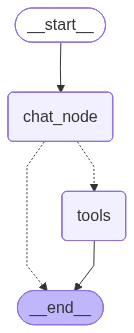

In [35]:
graph = StateGraph(ChatState)
graph.add_node('chat_node', chat_node)
graph.add_node('tools', tool_node)

graph.add_edge(START, 'chat_node')
graph.add_conditional_edges('chat_node', tools_condition)
# graph.add_edge('tools', 'chat_node')
graph.add_edge('chat_node', END)

chatbot = graph.compile()
chatbot

In [36]:
while True:
    input_msg = input("> ")

    if input_msg in ["q"]:
        break
    initial_state = {
        "messages" : [HumanMessage(content=input_msg)]
    }
    response = chatbot.invoke(initial_state)["messages"][-1].content
    print(": ", response)

>  what is the candidate's name?


:  
            Document: 1
            Source: CV.pdf
            Page: 0
            Content: Thiwanka Pathirana
Computer Science & Engineering Undergraduate
/envel⌢pethiwanka.21@cse.mrt.ac.lk♂phone+94 768643102
/linkedinlinkedin.com/in/thiwnanka/♂¶ap-¶arkerKuliyapitiya, Sri Lanka
/githubgithub.com/ThiwankaRoshen
About
Software Engineering undergraduate at the University of Moratuwa with hands-on internship experience
in R&D, building AI-driven and backend systems. Skilled in Python, FastAPI, cloud-native deployment,
and multi-agent workflows (LangGraph, A WS Bedrock), with a strong focus on solving real-world problems
through scalable and maintainable engineering.
Education
• University of Moratuwa2022 – Present
B.Sc. (Hons) Engineering — Computer Science & Engineering (Data Science & Engineering)
• Saranath College2012 – 2020
Secondary Education
–G.C.E. Advanced Level (2020):3A — Island Rank - 635
– G.C.E. Ordinary Level (2017):8A - 1B
Experience
• Codegen (Pvt) LtdDec 2024 – May 2

>  q


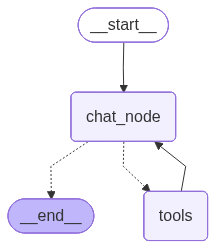

In [37]:
graph = StateGraph(ChatState)
graph.add_node('chat_node', chat_node)
graph.add_node('tools', tool_node)

graph.add_edge(START, 'chat_node')
graph.add_conditional_edges('chat_node', tools_condition)
graph.add_edge('tools', 'chat_node')
graph.add_edge('chat_node', END)

chatbot = graph.compile()
chatbot

In [38]:
while True:
    input_msg = input("> ")

    if input_msg in ["q"]:
        break
    initial_state = {
        "messages" : [HumanMessage(content=input_msg)]
    }
    response = chatbot.invoke(initial_state)["messages"][-1].content
    print(": ", response)

>  what is the candidate's name?


:  The candidate's name is Thiwanka Pathirana.


>  q
